In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from scipy.stats import entropy as scipy_entropy
from tqdm import tqdm
from transformers import AutoProcessor

import os
from vla.constants import PROJECT_ROOT
from vla.models.smolvla import SmolVLAPolicy


c:\Users\canic\DTU\Bachelor\vla-robotics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
suite_name = "object"
target_word = "juice"
frame_range = range(0, 110)  # Frames 0000 to 0109

# Resolve paths
task_dir_name = os.listdir(PROJECT_ROOT / "data/images/libero" / suite_name)[0]
image_dir = PROJECT_ROOT / "data/images/libero" / suite_name / "ep0000_task_0"
task_path = PROJECT_ROOT / "data/images/libero" / suite_name / task_dir_name / "task.txt"

with open(task_path) as f:
    task_description = f.read().strip()

print(f"Task: {task_description}")
print(f"Frames: {frame_range.start:04d} – {frame_range.stop - 1:04d} ({len(frame_range)} total)")

Task: pick up the orange juice and place it in the basket
Frames: 0000 – 0109 (110 total)


In [3]:
checkpoint = "HuggingFaceVLA/smolvla_libero"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading model from checkpoint: {checkpoint} on device: {device}")
policy = SmolVLAPolicy(checkpoint=checkpoint, device=device, action_dim=7)

Loading model from checkpoint: HuggingFaceVLA/smolvla_libero on device: cuda

'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /HuggingFaceVLA/smolvla_libero/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 8e7db849-0197-489a-9480-ab86d3cddfdf)')' thrown while requesting HEAD https://huggingface.co/HuggingFaceVLA/smolvla_libero/resolve/main/config.json
Retrying in 1s [Retry 1/5].


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /HuggingFaceVLA/smolvla_libero/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 229d5fac-79b5-4631-b745-9178925782a5)')' thrown while requesting HEAD https://huggingface.co/HuggingFaceVLA/smolvla_libero/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /HuggingFaceVLA/smolvla_libero/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 1d8379b7-8c4a-4048-9f5e-7e2c3ece4cf0)')' thrown while requesting HEAD https://huggingface.co/HuggingFaceVLA/smolvla_libero/resolve/main/config.json
Retr

Loading  HuggingFaceTB/SmolVLM2-500M-Instruct weights ...


`torch_dtype` is deprecated! Use `dtype` instead!


In [4]:
# %% Setup: processor, hooks, and model references (done ONCE)
hf_vlm = policy.model.vlm_with_expert.vlm
llm = hf_vlm.model.text_model
total_layers = len(llm.layers)
layer_indices = list(range(total_layers // 2))  # SmolVLA discards final 50%
vision_dtype = next(hf_vlm.model.vision_model.parameters()).dtype

# Force eager attention output
llm.config._attn_implementation = "eager"
llm.config.output_attentions = True

# Load processor ONCE
try:
    processor = AutoProcessor.from_pretrained("HuggingFaceVLA/smolvla_libero")
except Exception:
    processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM2-500M-Instruct")

# Pre-compute the text prompt template (same for every frame)
messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": task_description}]}]
prompt_template = processor.apply_chat_template(messages, add_generation_prompt=True)

print(f"Model ready — {total_layers} total layers, using first {len(layer_indices)}")
print(f"Processor loaded, prompt template cached.")


Model ready — 32 total layers, using first 16
Processor loaded, prompt template cached.


In [5]:
def get_attention_for_image(pil_image, device="cuda"):
    """
    Runs a single forward pass and returns attention maps for one image.
    Uses the pre-loaded processor, prompt template, and model references.
    """
    attention_maps = {}

    def get_forward_hook(layer_idx):
        def hook(module, input, output):
            attention_maps[layer_idx] = output[1].detach().cpu()
        return hook

    # Register hooks
    hook_handles = []
    for idx in layer_indices:
        target_layer = llm.layers[idx].self_attn
        handle = target_layer.register_forward_hook(get_forward_hook(idx))
        hook_handles.append(handle)

    # Process image
    inputs = processor(text=prompt_template, images=pil_image, return_tensors="pt").to(device)
    inputs["pixel_values"] = inputs["pixel_values"].to(vision_dtype)

    with torch.no_grad():
        _ = hf_vlm(**inputs)

    # Clean up hooks
    for handle in hook_handles:
        handle.remove()

    return attention_maps, inputs


In [6]:
def build_attention_grid(attention_maps_dict, inputs, processor, target_word, layer_indices):
    """
    Assembles the 16 local-crop attention tokens into a spatial grid for each layer.
    Returns a dict {layer_idx: np.ndarray(H, W)} with RAW (un-normalised) grids.
    """
    # Find the target token index
    input_ids = inputs["input_ids"][0].tolist()
    tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)

    target_idx = -1
    for i, t in enumerate(tokens):
        if target_word.lower() in t.lower():
            target_idx = i
            break
    if target_idx == -1:
        target_idx = len(input_ids) - 1

    # Find image token indices
    most_common_token = Counter(input_ids).most_common(1)[0][0]
    image_token_indices = [i for i, token in enumerate(input_ids) if token == most_common_token]
    num_crops = inputs["pixel_values"].shape[1]
    tokens_per_crop = len(image_token_indices) // num_crops
    grid_size = int(np.sqrt(tokens_per_crop))  # 8

    # Build list of token indices per local crop (exclude the last global crop)
    num_local_crops = num_crops - 1
    crop_token_indices = [
        image_token_indices[c * tokens_per_crop : (c + 1) * tokens_per_crop]
        for c in range(num_local_crops)
    ]

    n_crop_cols = int(np.sqrt(num_local_crops))
    n_crop_rows = int(np.ceil(num_local_crops / n_crop_cols))
    full_grid_h = n_crop_rows * grid_size
    full_grid_w = n_crop_cols * grid_size

    grids = {}
    for layer_idx in layer_indices:
        attn = attention_maps_dict[layer_idx].squeeze(0).mean(dim=0)  # avg heads
        word_attn = attn[target_idx, :]

        full_grid = np.zeros((full_grid_h, full_grid_w), dtype=np.float32)
        for c, crop_indices in enumerate(crop_token_indices):
            crop_row = c // n_crop_cols
            crop_col = c % n_crop_cols
            crop_attn = word_attn[crop_indices]
            if crop_attn.dtype == torch.bfloat16:
                crop_attn = crop_attn.to(torch.float32)
            patch = crop_attn.numpy().reshape(grid_size, grid_size)
            full_grid[
                crop_row * grid_size : (crop_row + 1) * grid_size,
                crop_col * grid_size : (crop_col + 1) * grid_size,
            ] = patch

        grids[layer_idx] = full_grid

    return grids

In [7]:
# multi frame extraction
import time

print(f"\n{'='*60}")
print(f"Extracting attention for {len(frame_range)} frames...")
print(f"{'='*60}\n")

# Accumulator: {layer_idx: list of (H, W) arrays}
all_grids = {}
per_frame_mean_attention = {}  # {layer_idx: list of scalar}
reference_image = None  # store first frame for overlays

start_time = time.time()

for frame_num in tqdm(frame_range, desc="Processing frames"):
    frame_str = f"{frame_num:04d}"
    img_path = image_dir / f"frame{frame_str}.png"

    if not img_path.exists():
        print(f"  Skipping missing frame: {frame_str}")
        continue

    image = Image.open(img_path).convert("RGB")
    if reference_image is None:
        reference_image = image

    # Forward pass (uses pre-loaded processor + prompt template)
    attn_maps, inputs = get_attention_for_image(image, device)

    # Build spatial grids
    grids = build_attention_grid(attn_maps, inputs, processor, target_word, layer_indices)

    for layer_idx, grid in grids.items():
        all_grids.setdefault(layer_idx, []).append(grid)
        per_frame_mean_attention.setdefault(layer_idx, []).append(float(grid.mean()))

    # Free GPU memory
    del attn_maps, inputs
    torch.cuda.empty_cache()

elapsed = time.time() - start_time
n_frames_processed = len(all_grids[layer_indices[0]])
print(f"\nProcessed {n_frames_processed} frames in {elapsed:.1f}s ({elapsed/n_frames_processed:.2f}s/frame)")

# Stack into arrays: {layer_idx: (N, H, W)}
for layer_idx in all_grids:
    all_grids[layer_idx] = np.stack(all_grids[layer_idx], axis=0)


Extracting attention for 110 frames...



Processing frames: 100%|██████████| 110/110 [01:45<00:00,  1.04it/s]


Processed 110 frames in 105.9s (0.96s/frame)


In [8]:
# Compute aggregated statistics
mean_grids = {}   # {layer_idx: (H, W)}
std_grids = {}    # {layer_idx: (H, W)}

for layer_idx in layer_indices:
    mean_grids[layer_idx] = all_grids[layer_idx].mean(axis=0)
    std_grids[layer_idx] = all_grids[layer_idx].std(axis=0)

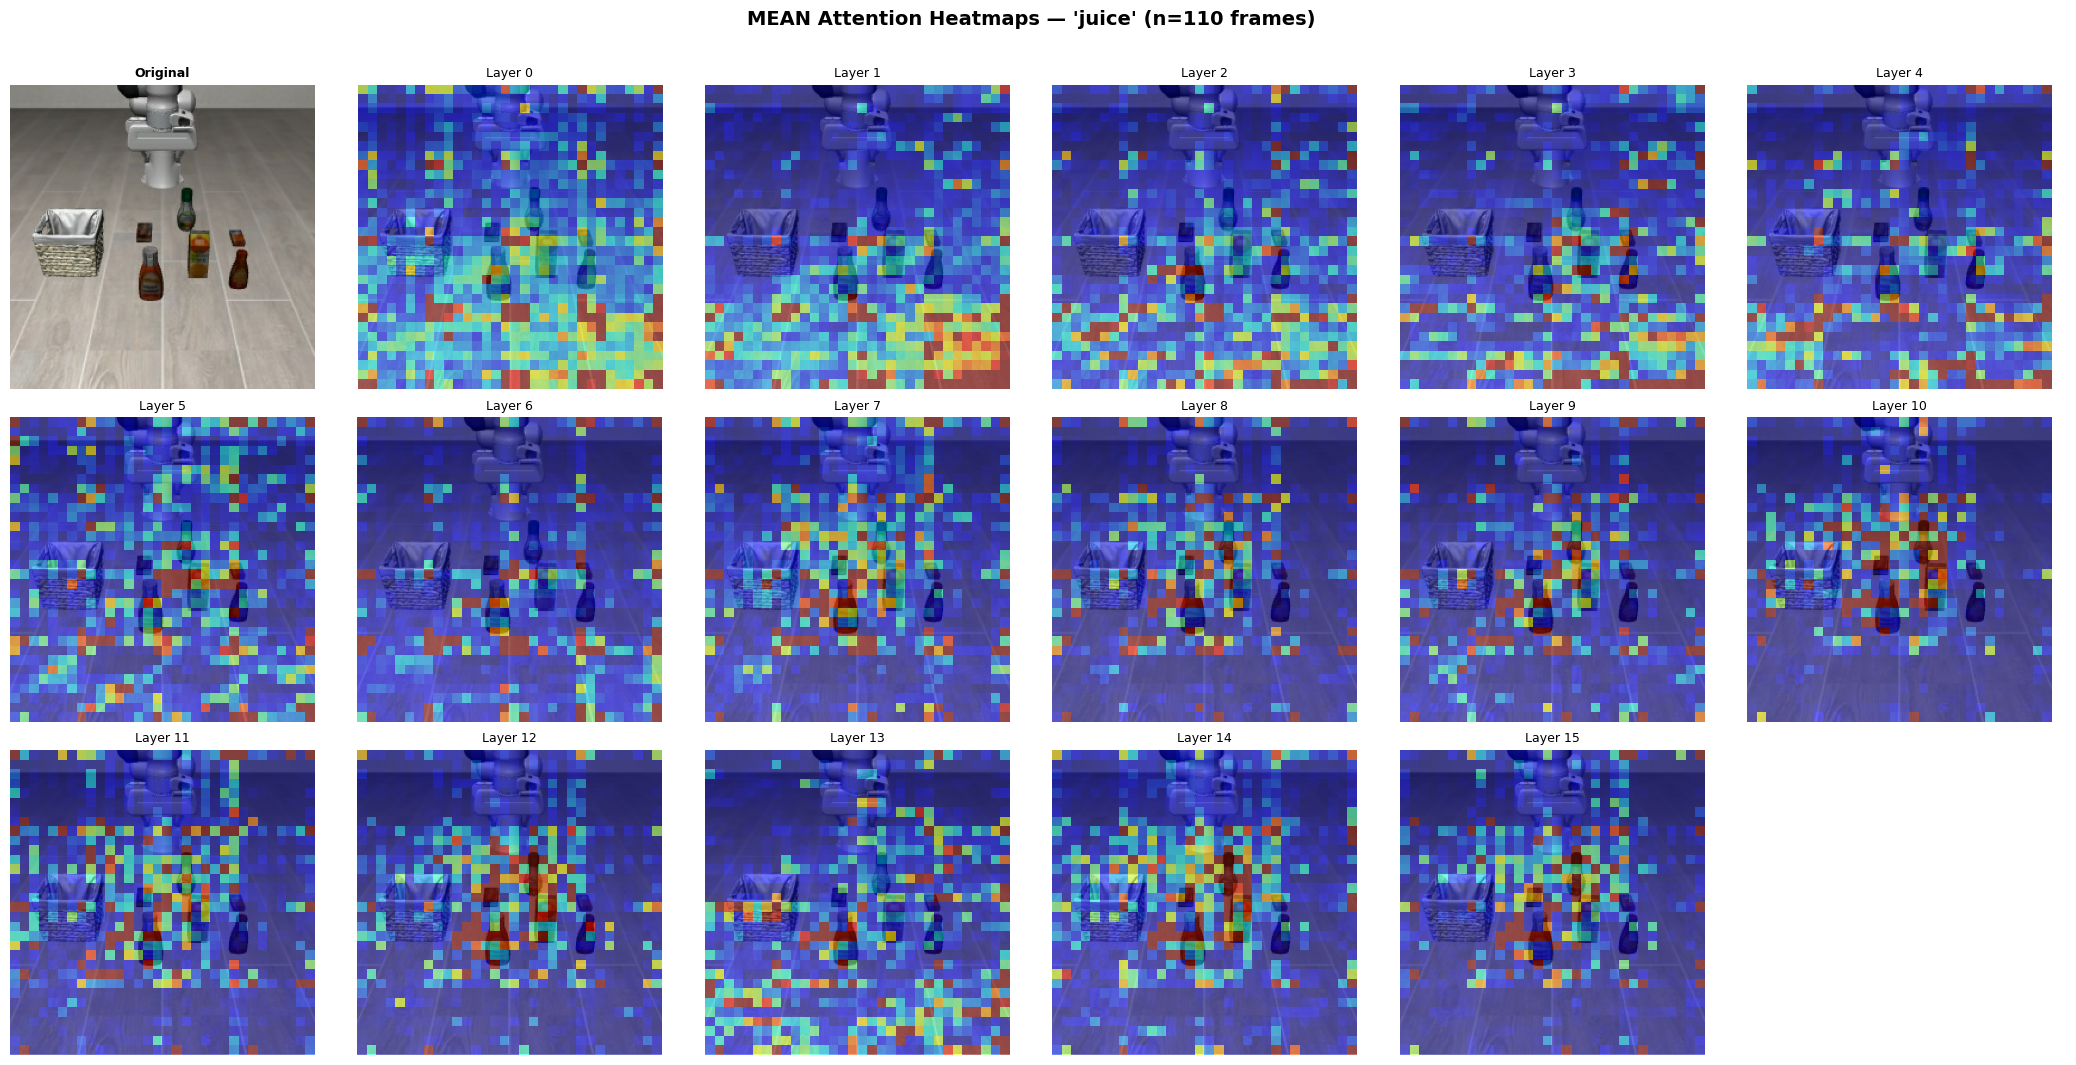

In [9]:
def plot_heatmap_grid(grids_dict, pil_image, layer_indices, target_word,
                      title, cmap="jet", n_cols=6):
    """
    Plots heatmaps for ALL layers in a grid layout.
    First cell is the original image, rest are one per layer.
    """
    num_plots = len(layer_indices) + 1  # +1 for original image
    n_rows = int(np.ceil(num_plots / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3.5 * n_cols, 3.5 * n_rows),
                             squeeze=False)
    axes_flat = axes.flatten()

    # Original image in first cell
    axes_flat[0].imshow(pil_image)
    axes_flat[0].set_title("Original", fontsize=9, fontweight="bold")
    axes_flat[0].axis("off")

    for plot_idx, layer_idx in enumerate(layer_indices):
        grid = grids_dict[layer_idx].copy()
        # Normalise for display
        vmin, vmax = np.percentile(grid, [2, 95])
        grid = np.clip(grid, vmin, vmax)
        grid = (grid - grid.min()) / (grid.max() - grid.min() + 1e-8)

        ax = axes_flat[plot_idx + 1]
        ax.imshow(pil_image)
        ax.imshow(grid, cmap=cmap, alpha=0.55,
                  extent=[0, pil_image.width, pil_image.height, 0])
        ax.set_title(f"Layer {layer_idx}", fontsize=9)
        ax.axis("off")

    # Hide unused cells
    for i in range(num_plots, len(axes_flat)):
        axes_flat[i].axis("off")

    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# --- Mean heatmap (all 16 layers) ---
plot_heatmap_grid(
    mean_grids, reference_image, layer_indices, target_word,
    title=f"MEAN Attention Heatmaps — '{target_word}' (n={n_frames_processed} frames)"
)

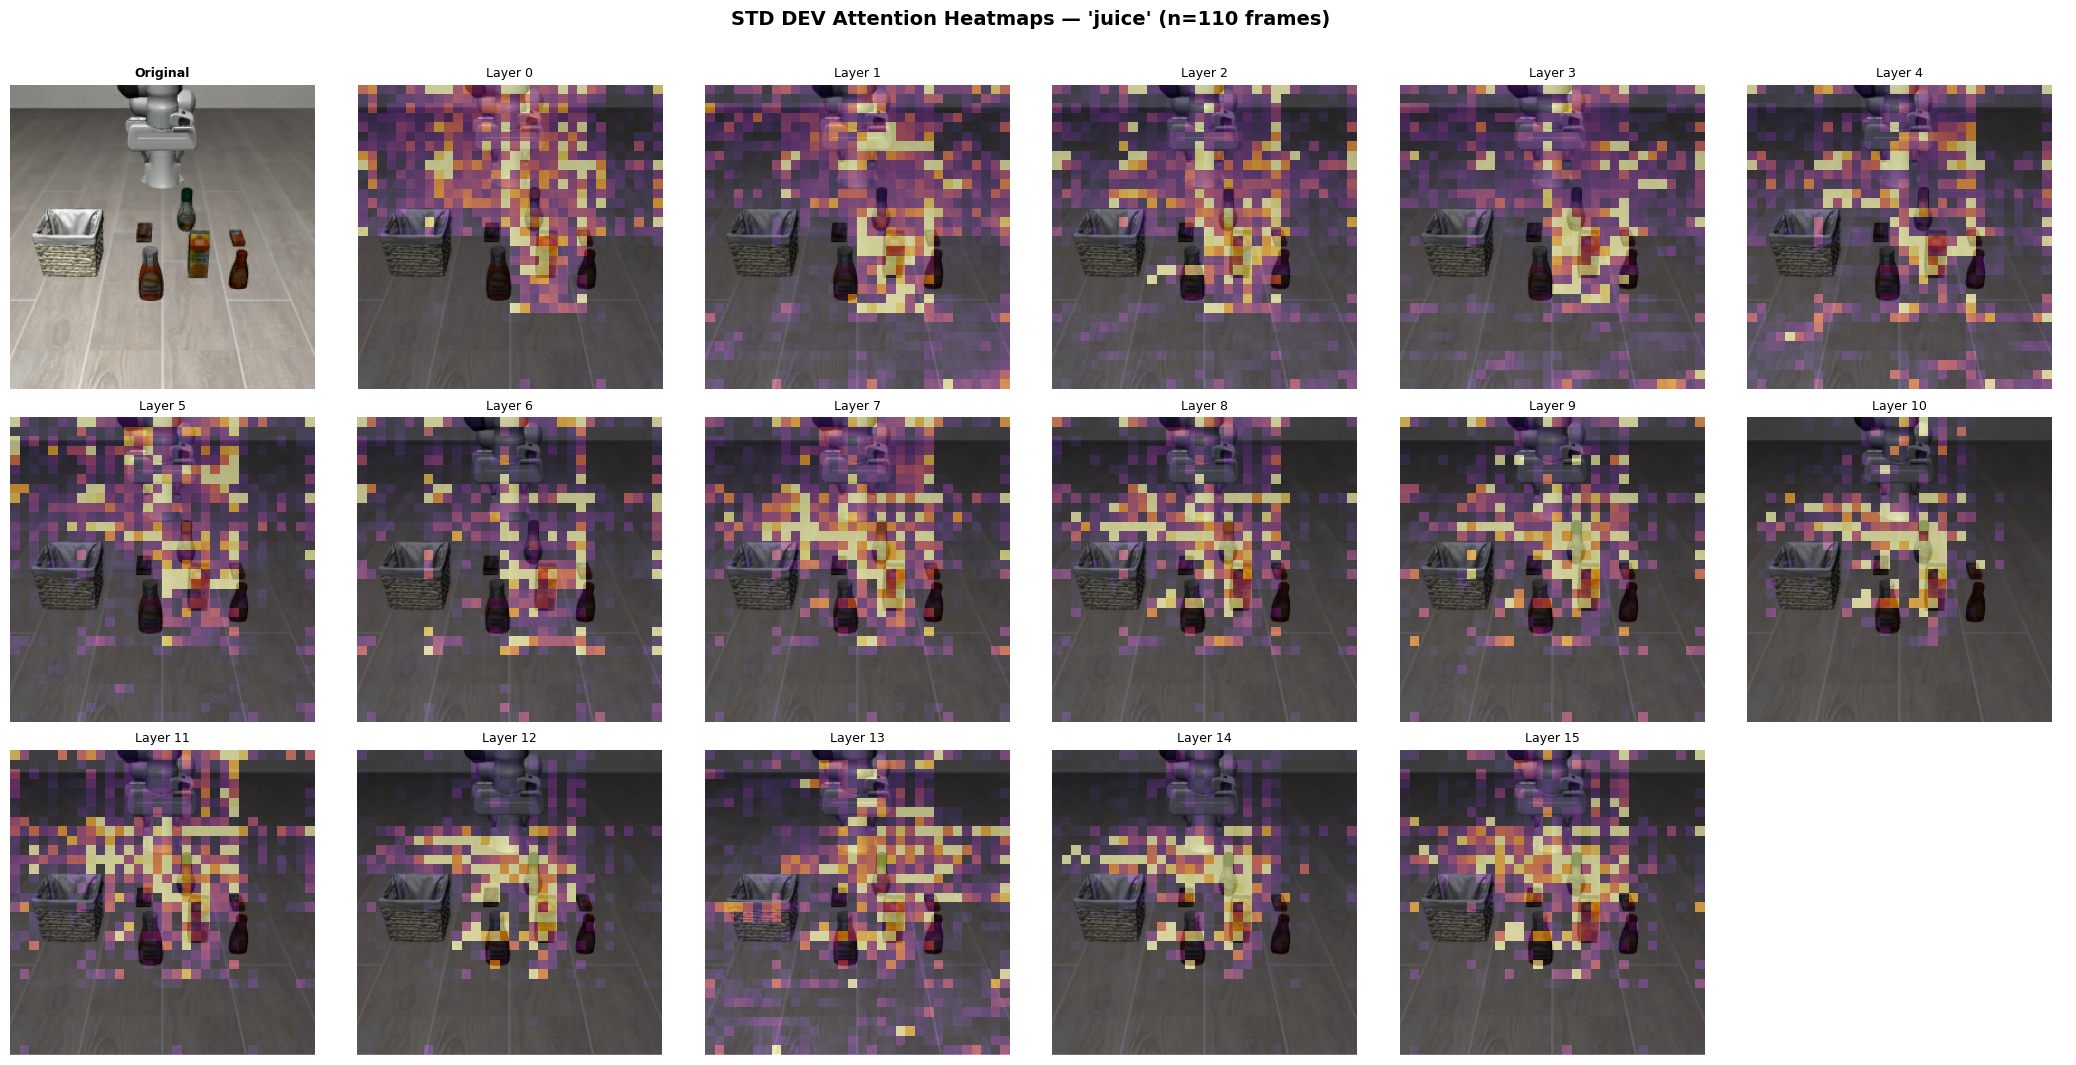

In [10]:
plot_heatmap_grid(
    std_grids, reference_image, layer_indices, target_word,
    title=f"STD DEV Attention Heatmaps — '{target_word}' (n={n_frames_processed} frames)",
    cmap="inferno"
)


In [11]:
def compute_metrics_table(mean_grids, std_grids, layer_indices):
    """
    Computes per-layer quantitative metrics from the aggregated attention grids.
    """
    rows = []
    for layer_idx in layer_indices:
        mg = mean_grids[layer_idx]
        sg = std_grids[layer_idx]

        # Flatten for entropy
        flat = mg.flatten()
        flat_norm = flat / (flat.sum() + 1e-12)  # make it a distribution
        spatial_ent = scipy_entropy(flat_norm, base=2)

        peak_pos = np.unravel_index(mg.argmax(), mg.shape)

        rows.append({
            "Layer": layer_idx,
            "Mean Attention": f"{mg.mean():.6f}",
            "Max Attention": f"{mg.max():.6f}",
            "Peak (row, col)": f"({peak_pos[0]}, {peak_pos[1]})",
            "Spatial Entropy (bits)": f"{spatial_ent:.2f}",
            "Mean Std Dev": f"{sg.mean():.6f}",
        })

    df = pd.DataFrame(rows)
    return df


metrics_df = compute_metrics_table(mean_grids, std_grids, layer_indices)
print("\n" + "=" * 70)
print(f"Per-Layer Quantitative Metrics (aggregated over {n_frames_processed} frames)")
print("=" * 70)
print(metrics_df.to_string(index=False))
print()

# Save to CSV
# metrics_df.to_csv("attention_metrics.csv", index=False)
# print("Saved: attention_metrics.csv")


Per-Layer Quantitative Metrics (aggregated over 110 frames)
 Layer Mean Attention Max Attention Peak (row, col) Spatial Entropy (bits) Mean Std Dev
     0       0.000627      0.003981        (31, 25)                   9.85     0.000032
     1       0.000033      0.000856        (31, 25)                   9.01     0.000002
     2       0.000056      0.001462        (19, 12)                   9.05     0.000006
     3       0.000059      0.001297        (31, 28)                   8.95     0.000005
     4       0.000010      0.000239        (31, 25)                   8.64     0.000001
     5       0.000010      0.000180        (17, 16)                   9.15     0.000002
     6       0.000026      0.001472        (24, 31)                   7.59     0.000004
     7       0.000021      0.000439        (24, 31)                   8.75     0.000007
     8       0.000055      0.002117        (19, 11)                   7.93     0.000026
     9       0.000007      0.000216        (19, 11)        

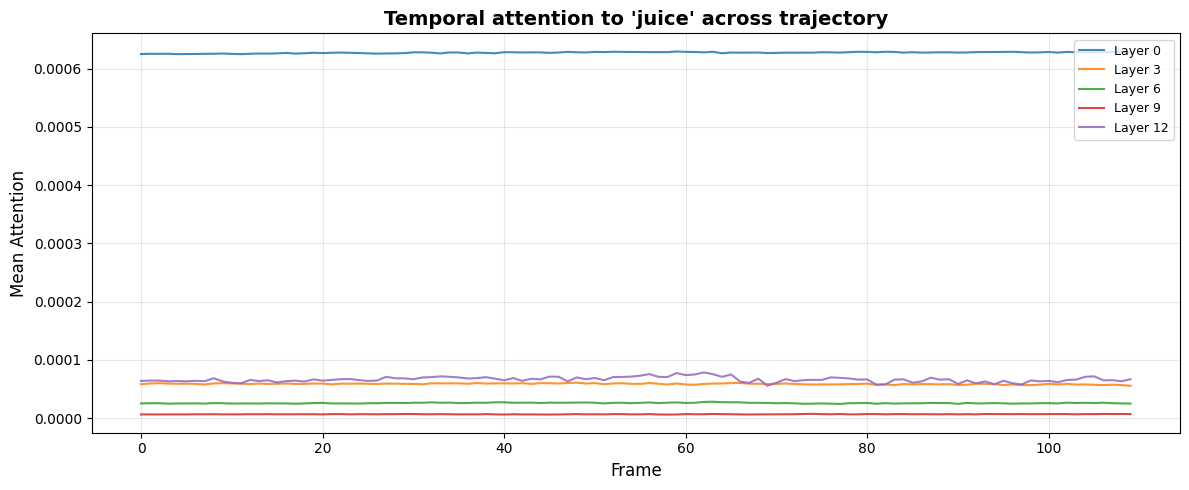

Saved: temporal_attention.png


In [12]:
def plot_temporal_attention(per_frame_mean_attention, layer_indices, target_word,
                             n_display=5):
    """
    Plots the mean attention magnitude per frame for a subset of layers.
    Shows how the model's attention to the target word evolves over the trajectory.
    """
    step = max(1, len(layer_indices) // n_display)
    display_layers = layer_indices[::step][:n_display]

    fig, ax = plt.subplots(figsize=(12, 5))

    for layer_idx in display_layers:
        values = per_frame_mean_attention[layer_idx]
        ax.plot(values, label=f"Layer {layer_idx}", alpha=0.85, linewidth=1.5)

    ax.set_xlabel("Frame", fontsize=12)
    ax.set_ylabel("Mean Attention", fontsize=12)
    ax.set_title(
        f"Temporal attention to '{target_word}' across trajectory",
        fontsize=14, fontweight="bold"
    )
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("temporal_attention.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: temporal_attention.png")


plot_temporal_attention(per_frame_mean_attention, layer_indices, target_word)

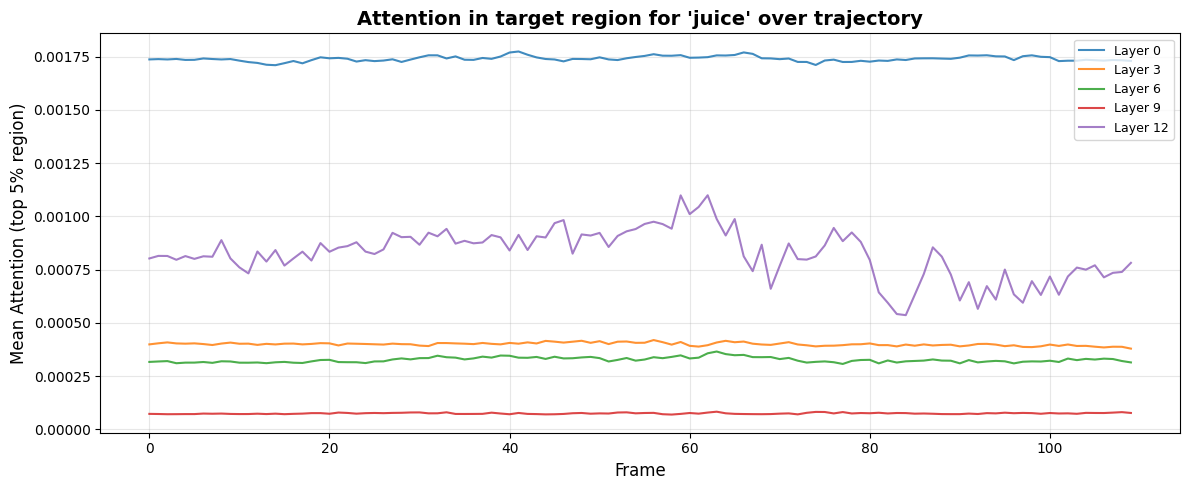

In [13]:
def plot_focused_region_temporal(all_grids, mean_grids, layer_indices, target_word,
                                  top_percentile=95, n_display=5):
    """
    Identifies the top-attention region from the mean heatmap and tracks
    attention in that region across frames. This is a more targeted metric
    than the full-grid mean.
    """
    step = max(1, len(layer_indices) // n_display)
    display_layers = layer_indices[::step][:n_display]

    fig, ax = plt.subplots(figsize=(12, 5))

    for layer_idx in display_layers:
        mg = mean_grids[layer_idx]
        threshold = np.percentile(mg, top_percentile)
        mask = mg >= threshold

        # For each frame, compute mean attention in the hot region
        region_means = []
        for frame_grid in all_grids[layer_idx]:
            region_means.append(float(frame_grid[mask].mean()))

        ax.plot(region_means, label=f"Layer {layer_idx}", alpha=0.85, linewidth=1.5)

    ax.set_xlabel("Frame", fontsize=12)
    ax.set_ylabel(f"Mean Attention (top {100 - top_percentile}% region)", fontsize=12)
    ax.set_title(
        f"Attention in target region for '{target_word}' over trajectory",
        fontsize=14, fontweight="bold"
    )
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig("focused_region_temporal.png", dpi=150, bbox_inches="tight")
    plt.show()
    # print("Saved: focused_region_temporal.png")


plot_focused_region_temporal(all_grids, mean_grids, layer_indices, target_word)

In [14]:
print("\n" + "=" * 70)
print("Analysis complete!")
print(f"  Frames processed : {n_frames_processed}")
print(f"  Layers analysed  : {len(layer_indices)}")
print(f"  Target word      : '{target_word}'")
print("=" * 70)
print("\nOutputs saved:")
print("  - aggregated_heatmaps.png")
print("  - attention_metrics.csv")
print("  - temporal_attention.png")
print("  - focused_region_temporal.png")


Analysis complete!
  Frames processed : 110
  Layers analysed  : 16
  Target word      : 'juice'

Outputs saved:
  - aggregated_heatmaps.png
  - attention_metrics.csv
  - temporal_attention.png
  - focused_region_temporal.png
